# 03 Exploratory Data Analysis (EDA)

## 1. Objective


##  Class Distribution Analysis

### Objective

Understand how the target variable is distributed and determine whether the dataset is balanced or imbalanced.

This analysis helps identify potential modeling challenges and guides the selection of appropriate evaluation metrics and sampling techniques.

### Business Question

Is the dataset balanced, or are fraudulent transactions significantly underrepresented compared to legitimate transactions?

### Why is this analysis important?

Before training any machine learning model, it is essential to understand the distribution of the target variable.

An imbalanced dataset can bias the model toward the majority class, leading to misleading evaluation results if accuracy is used as the primary metric.

Understanding the class distribution helps in selecting suitable preprocessing techniques, sampling strategies, and evaluation metrics.

In [ ]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option("display.max_columns", None)

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")


## 2. Import Libraries

In [3]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Display Settings
pd.set_option("display.max_columns", None)

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

## 3. Load Dataset


In [4]:
DATA_PATH = Path(r"D:\Fraud Detection\data\raw\creditcard.csv")
df = pd.read_csv(DATA_PATH)
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [5]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0



## 4. Univariate Analysis

In [7]:
class_counts = df['Class'].value_counts()

In [13]:
class_counts = df['Class'].value_counts()
class_pcts = df['Class'].value_counts(normalize=True) * 100

print(class_counts)
print(class_pcts.round(2))

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.83
1     0.17
Name: proportion, dtype: float64


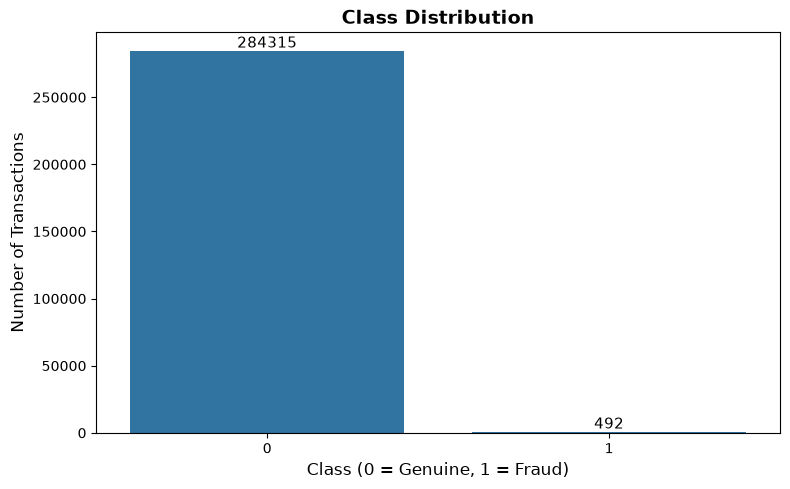

In [19]:
# Plot
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df, 
    x='Class'
)

#annotate class count
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.title('Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Class (0 = Genuine, 1 = Fraud)', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)

plt.tight_layout()

# Save Figure
plt.savefig(
    r"D:\Fraud Detection\reports\figures\class_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

##  Transaction Amount Analysis

### Objective

Analyze the distribution of transaction amounts to understand customer spending behavior, identify potential outliers, and determine whether transaction amount may influence fraud detection.

The findings from this analysis will also help decide whether feature scaling is required during preprocessing.

### Business Questions

1. How are transaction amounts distributed?
2. Are most transactions of low value or high value?
3. Are there any extreme transaction amounts (outliers)?
4. Is the distribution symmetric or skewed?
5. Does the Amount feature require scaling before model training?

### Why is this analysis important?

Transaction amount is one of the few features that retains its original business meaning.

Understanding its distribution helps identify customer spending patterns, detect unusually large transactions, and determine whether preprocessing techniques such as feature scaling or outlier handling are necessary.

In [21]:
amount_stats = df['Amount'].describe()
amount_stats

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

In [22]:
print("Descriptive Statistics")
print(amount_stats)

print("\nMedian Transaction Amount:")
print(df['Amount'].median())

print("\nStandard Deviation:")
print(df['Amount'].std())

print("\nVariance:")
print(df['Amount'].var())

print("\nSkewness:")
print(df['Amount'].skew())

Descriptive Statistics
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

Median Transaction Amount:
22.0

Standard Deviation:
250.12010924018855

Variance:
62560.06904632386

Skewness:
16.977724453761006


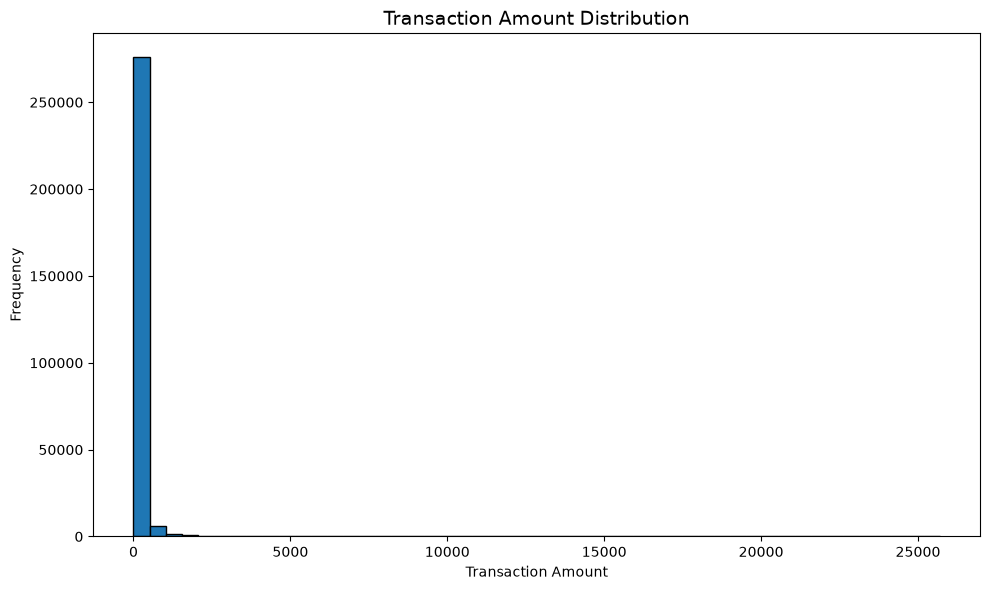

In [24]:
plt.figure(figsize=(10,6))

plt.hist(
    df['Amount'],
    bins=50,
    edgecolor = 'black'
)

plt.title('Transaction Amount Distribution', fontsize=14)
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')

plt.tight_layout()

plt.savefig(
    r"D:\Fraud Detection\reports\figures\amount_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

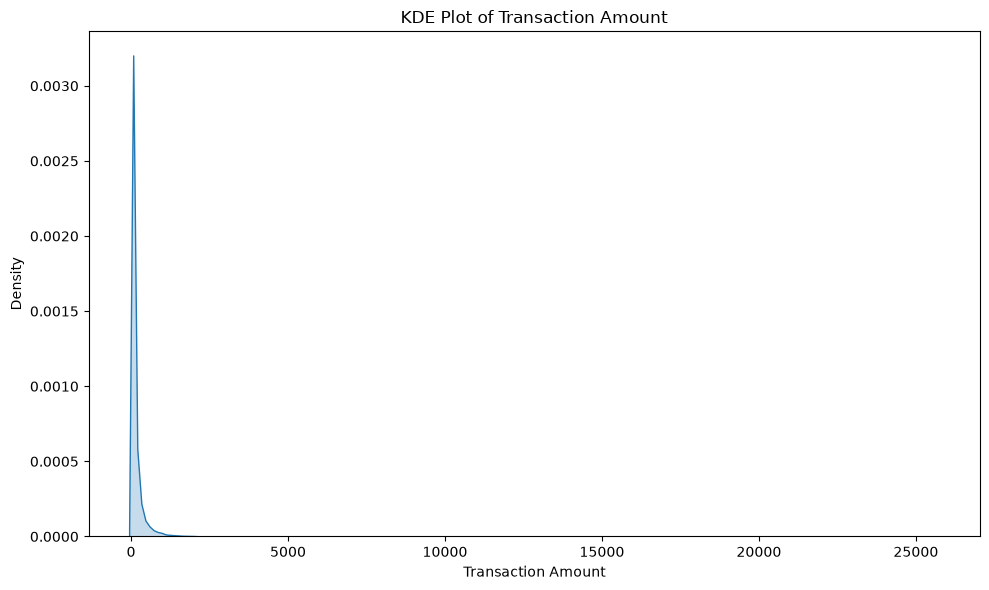

In [27]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df,
    x='Amount',
    fill=True
)

plt.title('KDE Plot of Transaction Amount')
plt.xlabel('Transaction Amount')

plt.tight_layout()

plt.savefig(
    r"D:\Fraud Detection\reports\figures\amount_distribution_kdeplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

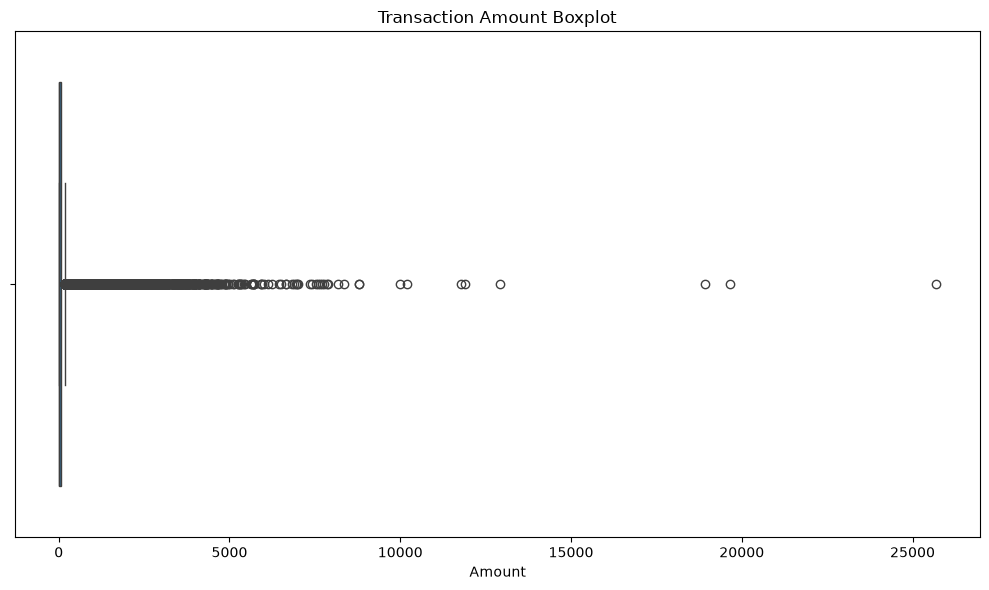

In [28]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=df['Amount']
)

plt.title('Transaction Amount Boxplot')

plt.tight_layout()

plt.savefig(
    r"D:\Fraud Detection\reports\figures\boxPLOT_amount_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

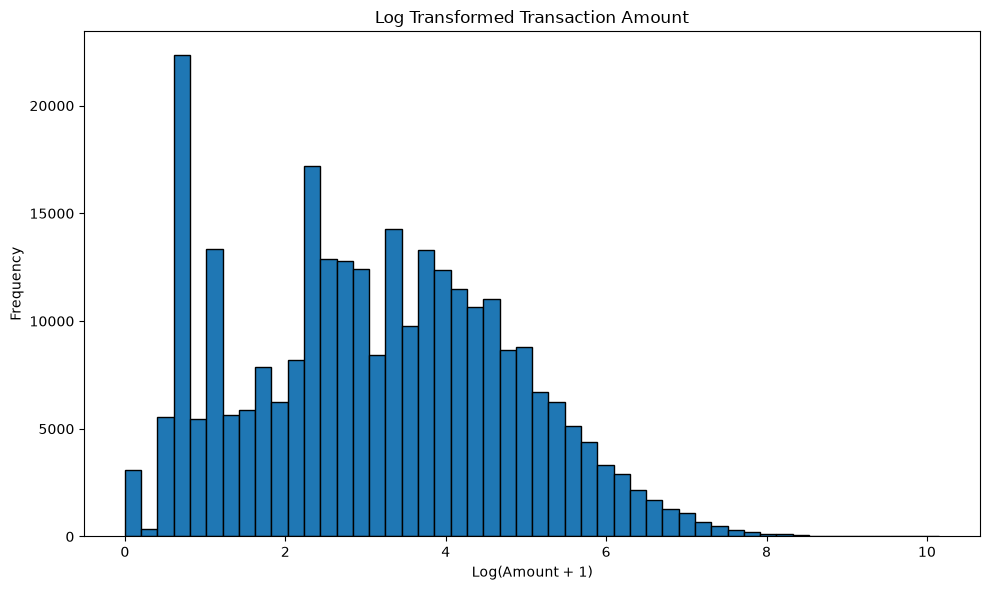

In [29]:
import numpy as np

plt.figure(figsize=(10,6))

plt.hist(
    np.log1p(df['Amount']),
    bins=50,
    edgecolor='black'
)

plt.title('Log Transformed Transaction Amount')
plt.xlabel('Log(Amount + 1)')
plt.ylabel('Frequency')

plt.tight_layout()

plt.savefig(
    r"D:\Fraud Detection\reports\figures\log_transform_plot.png",
    dpi=300,
    bbox_inches = 'tight'
)

plt.show()



## 5. Bivariate Analysis



## 6. Correlation Analysis



## 7. Outlier Analysis



## 8. Business Insights



## 9. Summary



## 10. Next Steps